# Start

In [ ]:
# # Code pour vider un dossier
# import os
# import shutil

# def clear_directory(path):
#     """
#     Supprime récursivement tout le contenu d'un répertoire donné,
#     puis recrée le répertoire vide.
#     """
#     if os.path.exists(path):
#         print(f"Suppression du contenu du dossier : {path}")
#         shutil.rmtree(path)
#         print(f"Dossier {path} et son contenu supprimés.")
#     else:
#         print(f"Le dossier {path} n'existe pas, pas de suppression nécessaire.")

#     os.makedirs(path, exist_ok=True)
#     print(f"Dossier {path} recréé et vide.")

# # --- Exemple d'utilisation (décommenter et remplacer 'YOUR_PATH_HERE') ---
# # ATTENTION: Assurez-vous que le chemin est correct, cette opération est irréversible.
# path_to_clear = "/content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+"
# clear_directory(path_to_clear)


## Imports

In [ ]:
!pip install mlflow -q
!pip install Pillow -q
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, applications
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import callbacks, losses, optimizers
import mlflow
from pathlib import Path
import mlflow
import pandas as pd
import os
import numpy as np
import tensorflow as tf
import cv2
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks, losses, metrics, optimizers
import mlflow
import mlflow.tensorflow

print("TensorFlow version:", tf.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 150.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 134.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras import mixed_precision

# Activation de la politique "mixed_float16"
# Cela permet d'utiliser des float16 pour les calculs (rapide) et float32 pour les variables (stable)
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Mixed precision policy:', policy.compute_dtype)

Mixed precision policy: float16


## CONFIG PATHS

In [ ]:
import os
from pathlib import Path
import mlflow

# --- CENTRALISATION DES CHEMINS (DRIVE) ---
PROJECT_ROOT = Path("/content/drive/MyDrive/P8")

# 1. Dossier Racine "Experiences"
EXP_ROOT = PROJECT_ROOT / "Experiences" / "Model_5_DeepLabV3+"

# 2. Sous-dossiers
# SEPARATION IMPORTANTE : On isole les logs MLflow dans 'mlruns'
# pour éviter qu'il ne scanne 'checkpoints' ou 'Models' comme des expériences.
MLFLOW_TRACKING_DIR = EXP_ROOT / "mlruns"
CHECKPOINTS_DIR     = EXP_ROOT / "checkpoints"
MODELS_DIR          = EXP_ROOT / "Models"
ARTIFACTS_DIR       = EXP_ROOT / "artefacts"

# Création automatique de l'arborescence
for path in [EXP_ROOT, MLFLOW_TRACKING_DIR, CHECKPOINTS_DIR, MODELS_DIR, ARTIFACTS_DIR]:
    if not path.exists():
        print(f"📁 Création dossier : {path}")
        path.mkdir(parents=True, exist_ok=True)

# Configuration MLflow immédiate
mlflow.set_tracking_uri("file://" + str(MLFLOW_TRACKING_DIR))

print("\n✅ CONFIGURATION TERMINÉE (Structure corrigée)")
print(f"📡 MLflow Tracking URI : {mlflow.get_tracking_uri()}")
print(f"💾 Checkpoints : {CHECKPOINTS_DIR}")
print(f"📦 Modèles Finaux : {MODELS_DIR}")

📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/mlruns
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/Models
📁 Création dossier : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/artefacts

✅ CONFIGURATION TERMINÉE (Structure corrigée)
📡 MLflow Tracking URI : file:///content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/mlruns
💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints
📦 Modèles Finaux : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/Models


In [ ]:
import os
from pathlib import Path
import mlflow

# Get the currently configured MLflow tracking URI
# Ensure MLFLOW_TRACKING_DIR is defined, if not, re-evaluate previous cells or set it here.
# Assuming MLFLOW_TRACKING_DIR from cell 'vzdfsFXfMy9c' is available:
mlflow_tracking_path = Path(mlflow.get_tracking_uri().replace("file://", ""))
mlflow_trash_dir = mlflow_tracking_path / ".trash"

# Create the .trash directory if it does not exist
if not mlflow_trash_dir.exists():
    try:
        mlflow_trash_dir.mkdir(parents=True, exist_ok=True)
        print(f"📁 Dossier MLflow .trash créé : {mlflow_trash_dir}")
    except Exception as e:
        print(f"⚠️ Erreur lors de la création du dossier MLflow .trash : {e}")
else:
    print(f"📁 Le dossier MLflow .trash existe déjà : {mlflow_trash_dir}")


📁 Dossier MLflow .trash créé : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/mlruns/.trash


## Mounting Drive

In [ ]:
import os
import shutil
from google.colab import drive

mount_point = '/content/drive'

# Check if the mount point exists and has contents
if os.path.exists(mount_point) and os.listdir(mount_point):
    print(f"Clearing existing contents in {mount_point} before mounting...")
    try:
        # Try to unmount first, in case it's a partially mounted or stale mount.
        # This command is often necessary before trying to clear or remount.
        _ = !fusermount -uz {mount_point}
        print(f"Successfully unmounted {mount_point}.")
    except Exception as e:
        print(f"Could not unmount {mount_point}: {e}. Proceeding with clearing directory.")

    # Remove all contents from the directory. If it was a broken mount, this cleans up.
    # If it's just a directory with files, this clears it for the mount.
    for item in os.listdir(mount_point):
        item_path = os.path.join(mount_point, item)
        try:
            if os.path.islink(item_path) or os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}. This might prevent successful mounting.")
            # We don't want to halt execution here, as drive.mount will raise if it's still an issue.

drive.mount(mount_point, force_remount=True)

Clearing existing contents in /content/drive before mounting...
Successfully unmounted /content/drive.
Mounted at /content/drive


## Initializing Repository

In [ ]:
import os
import glob

# 1. Définition des Chemins
# DRIVE_SOURCE = "/content/drive/MyDrive/P8"   # Là où sont stockés vos zips (Source lente)
DRIVE_SOURCE = "/content/drive/MyDrive/P8/Data" # Essayez celui-ci si le premier ne trouve rien

LOCAL_DEST = "/content/P8/Data"              # Là où on veut travailler (Destination rapide)

print(f"🔄 Initialisation de la copie : Drive -> {LOCAL_DEST}")

if not os.path.exists(LOCAL_DEST):
    os.makedirs(LOCAL_DEST)

# 2. Recherche automatique des fichiers ZIP sur le Drive
# On cherche tout ce qui commence par 'P8_Cityscapes' et finit par '.zip'
found_zips = glob.glob(os.path.join(DRIVE_SOURCE, "**", "P8_Cityscapes*.zip"), recursive=True)

if not found_zips:
    print("❌ ERREUR CRITIQUE : Aucun fichier zip trouvé dans le Drive !")
    print(f"J'ai cherché dans : {DRIVE_SOURCE}")
    print("Vérifiez le chemin exact dans la colonne de gauche 'drive > MyDrive > ...'")
else:
    print(f"✅ Fichiers ZIP trouvés sur le Drive : {len(found_zips)}")
    for zip_file in found_zips:
        print(f"   -> Copie et Décompression de : {os.path.basename(zip_file)} ...")
        # Unzip silencieux (-q) mais avec écrasement (-o) vers le dossier local
        !unzip -q -o "{zip_file}" -d "{LOCAL_DEST}"

    print("\n🎉 SUCCESS : Toutes les données sont prêtes sur le Disque Rapide !")

    # 3. Configuration des variables GLOBALES
    IMG_DIR = os.path.join(LOCAL_DEST, "leftImg8bit")
    MASK_DIR = os.path.join(LOCAL_DEST, "gtFine")

    print(f"📁 IMG_DIR = {IMG_DIR}")
    if os.path.exists(IMG_DIR):
         print(f"   Contenu : {os.listdir(IMG_DIR)}")
    else:
         print("⚠️ Attention : Le dossier leftImg8bit n'est pas apparu. Vérifiez la structure du zip.")

🔄 Initialisation de la copie : Drive -> /content/P8/Data
✅ Fichiers ZIP trouvés sur le Drive : 2
   -> Copie et Décompression de : P8_Cityscapes_gtFine_trainvaltest.zip ...
   -> Copie et Décompression de : P8_Cityscapes_leftImg8bit_trainvaltest.zip ...

🎉 SUCCESS : Toutes les données sont prêtes sur le Disque Rapide !
📁 IMG_DIR = /content/P8/Data/leftImg8bit
   Contenu : ['train', 'test', 'val']


# Data Preparing

## Loading Data

In [ ]:
from pathlib import Path
import os

# --- 1. CONFIGURATION DES CHEMINS ---

# DRIVE (Stockage Permanent Résultats)
PROJECT_ROOT = Path("/content/drive/MyDrive/P8")

# LOCAL (Stockage Temporaire Rapide pour Données)
# C'est ici que le script 'unzip' a déposé les images
DATA_DIR_LOCAL = Path("/content/P8/Data")

IMG_DIR = DATA_DIR_LOCAL / "leftImg8bit"
MASK_DIR = DATA_DIR_LOCAL / "gtFine"

# Vérification
print(f"📂 INPUT (Lecture Rapide) : {IMG_DIR} -> Exists? {IMG_DIR.exists()}")
print(f"💾 OUTPUT (Sauvegarde Drive) : {PROJECT_ROOT} -> Exists? {PROJECT_ROOT.exists()}")

if not IMG_DIR.exists():
    print("⚠️ ATTENTION : Les données locales ne sont pas trouvées. Avez-vous lancé le script 'Unzip' ?")

📂 INPUT (Lecture Rapide) : /content/P8/Data/leftImg8bit -> Exists? True
💾 OUTPUT (Sauvegarde Drive) : /content/drive/MyDrive/P8 -> Exists? True


In [ ]:
print("Cities train images:", os.listdir(os.path.join(IMG_DIR, "train"))[:3])
print("Cities train masks:", os.listdir(os.path.join(MASK_DIR, "train"))[:3])

Cities train images: ['bremen', 'aachen', 'cologne']
Cities train masks: ['bremen', 'aachen', 'cologne']


## Fonction de listing image / masque

In [ ]:
from glob import glob
from PIL import Image

def get_file_pairs(split="train"):
    img_paths = []
    mask_paths = []

    for city in os.listdir(os.path.join(IMG_DIR, split)):
        city_img_dir = os.path.join(IMG_DIR, split, city)
        city_mask_dir = os.path.join(MASK_DIR, split, city)

        for img_file in glob(os.path.join(city_img_dir, "*_leftImg8bit.png")):
            mask_file = os.path.join(
                city_mask_dir,
                os.path.basename(img_file).replace(
                    "_leftImg8bit.png",
                    "_gtFine_labelIds.png"
                )
            )

            if os.path.exists(mask_file):
                try:
                    with Image.open(img_file) as img_pil:
                        img_pil.verify()
                    with Image.open(mask_file) as mask_pil:
                        mask_pil.verify()

                    img_paths.append(img_file)
                    mask_paths.append(mask_file)
                except Exception as e:
                    print(f"Skipping corrupted image/mask pair (INVALID PNG DATA): {img_file}, {mask_file} - Error: {e}")
            else:
                print(f"Skipping image due to missing mask file: {img_file}")

    return img_paths, mask_paths


## Test du chargement des chemins

In [ ]:
train_imgs, train_masks = get_file_pairs("train")
val_imgs, val_masks = get_file_pairs("val")

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")

print(train_imgs[0])
print(train_masks[0])

Train images: 2975
Val images: 500
/content/P8/Data/leftImg8bit/train/bremen/bremen_000086_000019_leftImg8bit.png
/content/P8/Data/gtFine/train/bremen/bremen_000086_000019_gtFine_labelIds.png


## Chargement image + masque

In [ ]:
import cv2
import numpy as np

IMG_HEIGHT = 256
IMG_WIDTH = 512

CITYSCAPES_TO_8 = {
    7: 0, 8: 0,
    11: 1, 12: 1,
    13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2,
    24: 3, 25: 3,
    21: 4,
    23: 5,
    19: 6, 20: 6, 22: 6,
    9: 7, 10: 7, 0: 7
}

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT),
                      interpolation=cv2.INTER_NEAREST)

    new_mask = np.zeros_like(mask)
    for k, v in CITYSCAPES_TO_8.items():
        new_mask[mask == k] = v

    return img.astype(np.float32), new_mask.astype(np.uint8)


In [ ]:
# --- Paramètres du Pipeline ---
IMG_HEIGHT = 256
IMG_WIDTH = 512
BATCH_SIZE = 4
AUTOTUNE = tf.data.AUTOTUNE

# --- Mapping des Classes ---
# 7 classes retenues + 1 void
MAPPING_LIST = [
    7, 7, 7, 7, 7, 7, 7, # 0-6: void
    0, 0, 0, 0,          # 7-10: flat
    3, 3, 3, 3, 3, 3,    # 11-16: construction
    4, 4, 4, 4,          # 17-20: object
    5, 5,                # 21-22: nature
    6,                   # 23: sky
    1, 1,                # 24-25: human
    2, 2, 2, 2, 2, 2, 2, 2, # 26-33: vehicle
    7                    # 34: license plate
]
MAPPING_TENSOR = tf.constant(MAPPING_LIST + [7] * (256 - len(MAPPING_LIST)), dtype=tf.int32)

def parse_image_mask(img_path, mask_path):
    """ Chargement et prétraitement d'une image et de son masque """
    # 1. Image
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    # Normalisation [0,1] float32
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)

    # 2. Masque
    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    mask = tf.cast(mask, tf.int32)

    # 3. Mapping des classes
    mask = tf.gather(MAPPING_TENSOR, mask)

    return img, mask


import albumentations as A

aug_pipeline = A.Compose([
    # A.VerticalFlip(p=0.1),
    A.HorizontalFlip(p=0.2),
    A.RandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.7, 1.0), p=0.3),
    A.Rotate(limit=30, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0.2, p=0.1),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.2)
])

def augment_albumentations(img, mask):
    data = {"image": img, "mask": mask}
    aug_data = aug_pipeline(**data)
    return aug_data["image"], aug_data["mask"]

def augment(img, mask):
    aug_img, aug_mask = tf.numpy_function(func=augment_albumentations, inp=[img, mask], Tout=[tf.float32, tf.int32])
    aug_img.set_shape((IMG_HEIGHT, IMG_WIDTH, 3))
    aug_mask.set_shape((IMG_HEIGHT, IMG_WIDTH, 1))
    return aug_img, aug_mask

def create_dataset(img_paths, mask_paths, training=False, augment_data=False):
    """ Création du Dataset TensorFlow optimisé """
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    if training:
        dataset = dataset.shuffle(buffer_size=1000)

    # Chargement
    dataset = dataset.map(parse_image_mask, num_parallel_calls=AUTOTUNE)

    # Augmentation (albumentations)
    if training and augment_data:
        dataset = dataset.map(augment, num_parallel_calls=AUTOTUNE)

    # Batching
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=AUTOTUNE)

    return dataset

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Creating Datasets

In [ ]:
# Création des datasets
# Train avec augmentation
train_ds_aug = create_dataset(train_imgs, train_masks, training=True, augment_data=True)
# Train sans augmentation (pour comparaison)
train_ds_no_aug = create_dataset(train_imgs, train_masks, training=True, augment_data=False)
# Validation (jamais d'augmentation)
val_ds = create_dataset(val_imgs, val_masks, training=False)

print(f"Datasets créés. Batch size: {BATCH_SIZE}")
# Vérification d'un batch
for img, mask in train_ds_aug.take(1):
    print(f"Image shape: {img.shape}, Type: {img.dtype}")
    print(f"Mask shape: {mask.shape}, Type: {mask.dtype}")

Datasets créés. Batch size: 4
Image shape: (4, 256, 512, 3), Type: <dtype: 'float32'>
Mask shape: (4, 256, 512, 1), Type: <dtype: 'int32'>


### Vérification de l'augmentation des données

Visualisation des échantillons SANS augmentation:


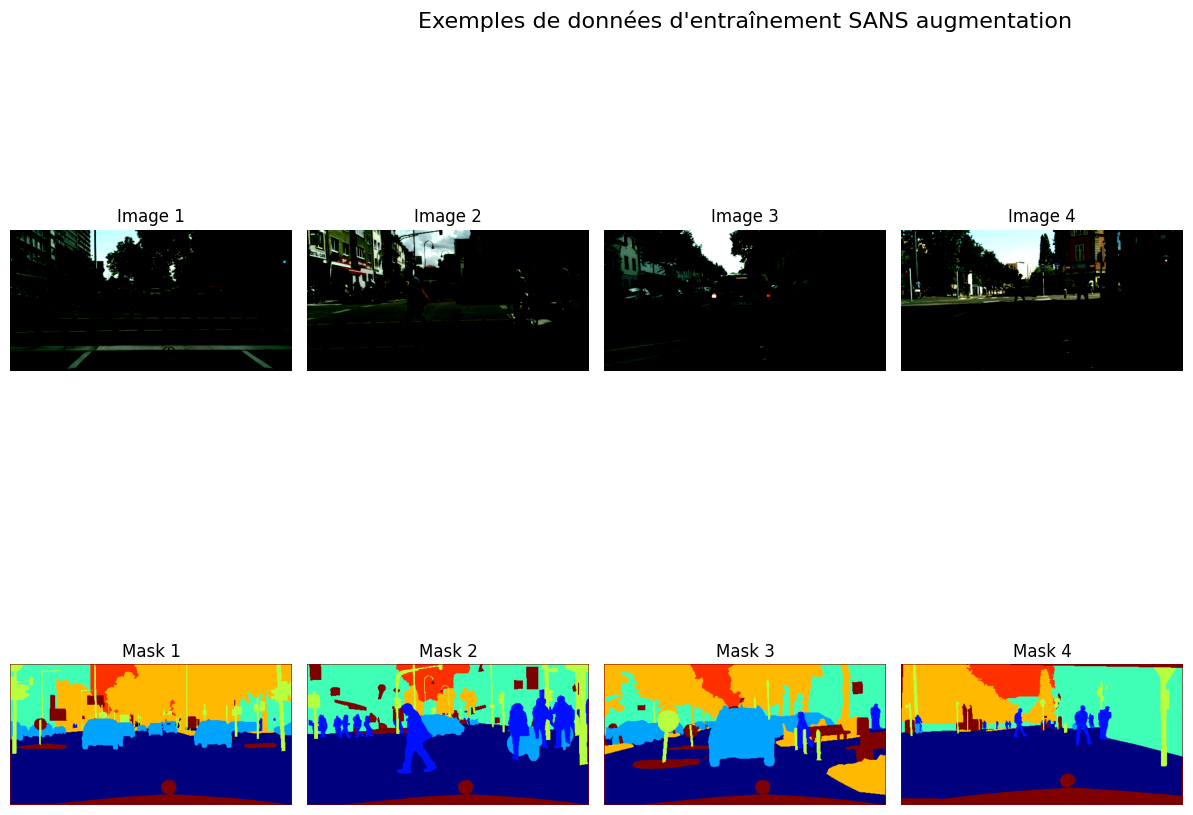


Visualisation des échantillons AVEC augmentation:


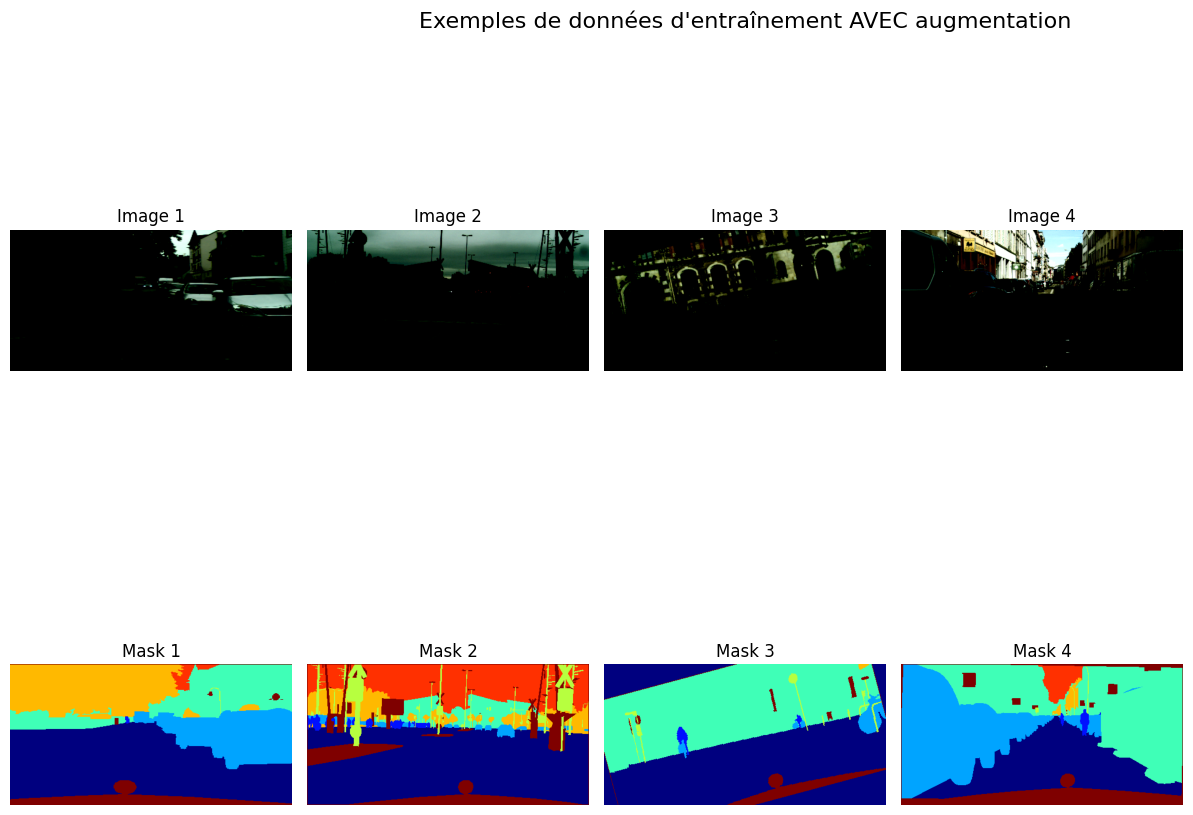

In [ ]:
import matplotlib.pyplot as plt

def visualize_augmented_samples(dataset, title, num_samples=5):
    plt.figure(figsize=(15, 2 * num_samples))
    plt.suptitle(title, fontsize=16)

    for i, (images, masks) in enumerate(dataset.take(1)):
        if i >= num_samples:
            break

        for j in range(num_samples):
            if j >= images.shape[0]: # Ensure we don't go out of bounds if batch size is smaller than num_samples
                break

            # Image
            plt.subplot(2, num_samples, j + 1)
            plt.imshow(tf.cast(images[j], tf.float32))
            plt.title(f"Image {j+1}")
            plt.axis("off")

            # Mask
            plt.subplot(2, num_samples, num_samples + j + 1)
            plt.imshow(masks[j], cmap='jet', vmin=0, vmax=7) # Using cmap='jet' for better visibility of classes
            plt.title(f"Mask {j+1}")
            plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Visualisation des échantillons SANS augmentation:")
visualize_augmented_samples(train_ds_no_aug, "Exemples de données d'entraînement SANS augmentation", num_samples=5)

print("\nVisualisation des échantillons AVEC augmentation:")
visualize_augmented_samples(train_ds_aug, "Exemples de données d'entraînement AVEC augmentation", num_samples=5)

# Modeling

# Loss function for optimizing models

In [ ]:
# --- Définition de la Dice Loss Custom ---
def dice_loss(y_true, y_pred):
    """
    Dice Loss pour segmentation multiclasse
    y_true: labels sparse (batch, h, w, 1) ou (batch, h, w)
    y_pred: probabilités (batch, h, w, num_classes)
    """
    y_true = tf.cast(y_true, tf.int32)
    # One-hot encoding du masque réel pour matcher la forme de y_pred
    y_true_one_hot = tf.one_hot(tf.squeeze(y_true), depth=8) # 8 classes

    numerator = 2 * tf.reduce_sum(y_true_one_hot * y_pred, axis=(0,1,2))
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=(0,1,2))

    # Dice par classe (ajout d'un epsilon pour éviter division par 0)
    dice_score = (numerator + 1e-7) / (denominator + 1e-7)

    # On renvoie 1 - dice_moyen
    return 1 - tf.reduce_mean(dice_score)

# --- Définition de la Loss Combinée (Combo Loss) ---
def combo_loss(y_true, y_pred):
    # Poids pour équilibrer (souvent 1:1 marche bien)
    ce = losses.sparse_categorical_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return ce + dice

# --- Mise à jour de la configuration ---
# On utilise maintenant notre combo_loss au lieu de juste Crossentropy
# loss_fn = losses.SparseCategoricalCrossentropy()  <-- Ancienne
loss_fn = combo_loss
optimizer = optimizers.Adam(learning_rate=2e-5)

# Training function

In [ ]:
def train_model(model, train_ds, val_ds, run_name, epochs=15):
    print(f"\n🚀 DÉMARRAGE RUN : {run_name}")
    # A. Préparation Checkpoint (Sur le Drive)
    run_ckpt_dir = CHECKPOINTS_DIR / run_name

    if not run_ckpt_dir.exists():
        run_ckpt_dir.mkdir(parents=True, exist_ok=True)

    ckpt_path = str(run_ckpt_dir / "best_model.keras")
    print(f"💾 Checkpoints : {ckpt_path}")

    # B. Callbacks
    ckpt_callback = callbacks.ModelCheckpoint(
        filepath=ckpt_path,
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )
    es_callback = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    lr_callback = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.8,
        patience=3,
        verbose=1,
        min_lr=1e-6
    )

    # C. Compilation
    # Ajout de run_eagerly=True pour éviter le problème avec LossScaleOptimizer et le mode graph.
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'], run_eagerly=True)

    # D. MLflow Run
    # On force l'expérience pour être sûr
    mlflow.set_experiment("Segmentation_Model_5_DeepLabV3+")

    with mlflow.start_run(run_name=run_name) as run:
        # Log params
        mlflow.log_params({
            "model": model.name,
            "epochs": epochs,
            "optimizer": "adam",
            "loss": "combo_loss" if loss_fn == combo_loss else "scce"
        })

        # Autolog (courbes) sans les modèles lourds
        mlflow.tensorflow.autolog(log_models=False)

        # Entraînement
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=[ckpt_callback, es_callback, lr_callback]
        )

        # --- E. Évaluation Détaillée (IoU / Dice) ---
        print("\n📊 Calcul des métriques détaillées par classe...")
        total_cm = np.zeros((8, 8))

        for images, masks in val_ds:
            preds = model.predict(images, verbose=0)
            preds_cls = np.argmax(preds, axis=-1)
            masks_np = masks.numpy().flatten()
            preds_np = preds_cls.flatten()

            # Confusion Matrix
            cm = tf.math.confusion_matrix(masks_np, preds_np, num_classes=8).numpy()
            total_cm += cm

        # Calculs
        iou_list = []
        dice_list = []
        classes = ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']

        print(f"\n{'CLASSE':<12} | {'IoU':<8} | {'Dice':<8}")
        print("-" * 35)

        for i in range(8):
            tp = total_cm[i, i]
            fp = np.sum(total_cm[:, i]) - tp
            fn = np.sum(total_cm[i, :]) - tp

            # IoU
            denom_iou = tp + fp + fn
            iou = tp / denom_iou if denom_iou > 0 else 0
            iou_list.append(iou)

            # Dice
            denom_dice = 2 * tp + fp + fn
            dice = 2 * tp / denom_dice if denom_dice > 0 else 0
            dice_list.append(dice)

            # Log & Print
            mlflow.log_metric(f"iou_class_{classes[i]}", iou)
            mlflow.log_metric(f"dice_class_{classes[i]}", dice)
            print(f"{classes[i]:<12} | {iou:.4f}   | {dice:.4f}")

        # Moyennes
        mean_iou = np.mean(iou_list)
        mean_dice = np.mean(dice_list)

        print("-" * 35)
        print(f"🏆 MEAN IoU: {mean_iou:.4f} | MEAN Dice: {mean_dice:.4f}")

        mlflow.log_metric("final_mean_iou", mean_iou)
        mlflow.log_metric("final_mean_dice", mean_dice)

        # Sauvegarde CSV
        df = pd.DataFrame({"Class": classes, "IoU": iou_list, "Dice": dice_list})
        csv_path = "classification_report.csv"
        df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)

        # F. Sauvegarde Modèle Final (Format Keras 3 .keras)
        # Dans Experiences/Models/RunName/
        run_model_dir = MODELS_DIR / run_name
        if not run_model_dir.exists():
            run_model_dir.mkdir(parents=True, exist_ok=True)

        final_model_path = str(run_model_dir / "final_model.keras")
        model.save(final_model_path)
        print(f"📦 Modèle final sauvegardé : {final_model_path}")

        # Log dans MLflow aussi (optionnel mais pratique)
        # mlflow.tensorflow.log_model(model, "model")

        print(f"✅ Run terminé avec succès.")
        return history

# Model DeepLabV3+

In [ ]:
# --- Modèle 3 : DeepLabV3+ (Official Structure) ---
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# IMPORTANT: On vide la session Keras pour s'assurer que les noms des couches ne s'incrémentent pas
# à chaque fois que la cellule est exécutée (sinon 'conv2d_4' deviendrait 'conv2d_14', etc.)
tf.keras.backend.clear_session()

def convolution_block(block_input, num_filters=256, kernel_size=3, dilation_rate=1, padding="same", use_bias=False):
    x = layers.Conv2D(
        num_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding=padding,
        use_bias=use_bias,
        kernel_initializer=tf.keras.initializers.HeNormal(),
    )(block_input)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def DilatedSpatialPyramidPooling(dspp_input):
    # global average pooling
    x = layers.GlobalAveragePooling2D()(dspp_input)
    x = layers.Reshape((1, 1, x.shape[-1]))(x)
    # 1x1 convolution with 256 filters
    x = convolution_block(x, num_filters=256, kernel_size=1, use_bias=True)
    # bilinearly upsample features
    out_pool = layers.Lambda(lambda tensors: tf.image.resize(tensors[0], tf.shape(tensors[1])[1:3]))([x, dspp_input])

    # one 1x1 convolution and three 3x3 convolutions pre-activation
    out_1 = convolution_block(dspp_input, num_filters=256, kernel_size=1, dilation_rate=1)
    out_6 = convolution_block(dspp_input, num_filters=256, kernel_size=3, dilation_rate=6)
    out_12 = convolution_block(dspp_input, num_filters=256, kernel_size=3, dilation_rate=12)
    out_18 = convolution_block(dspp_input, num_filters=256, kernel_size=3, dilation_rate=18)

    x = layers.Concatenate(axis=-1)([out_1, out_6, out_12, out_18, out_pool])
    output = convolution_block(x, num_filters=256, kernel_size=1)
    return output

def build_deeplabv3_plus(input_shape, num_classes=8):
    model_input = layers.Input(shape=input_shape)

    # 1. Backbone: ResNet50V2
    resnet50v2 = applications.ResNet50V2(
        weights="imagenet", include_top=False, input_tensor=model_input
    )

    # Extraction des features
    x = resnet50v2.get_layer("post_relu").output if "post_relu" in [layer.name for layer in resnet50v2.layers] else resnet50v2.get_layer("conv4_block6_out").output
    input_a = resnet50v2.get_layer("conv2_block3_1_relu").output if "conv2_block3_1_relu" in [layer.name for layer in resnet50v2.layers] else resnet50v2.get_layer("conv2_block3_out").output

    # 2. ASPP
    x = DilatedSpatialPyramidPooling(x)

    # 3. Decoder
    input_a = convolution_block(input_a, num_filters=48, kernel_size=1)

    x = layers.Lambda(lambda tensors: tf.image.resize(tensors[0], tf.shape(tensors[1])[1:3]))([x, input_a])
    x = layers.Concatenate(axis=-1)([x, input_a])

    x = convolution_block(x, num_filters=256)
    x = convolution_block(x, num_filters=256)

    x = layers.Lambda(lambda tensors: tf.image.resize(tensors[0], tf.shape(tensors[1])[1:3]))([x, model_input])
    model_output = layers.Conv2D(num_classes, kernel_size=(1, 1), padding="same", activation="softmax")(x)

    model = models.Model(inputs=model_input, outputs=model_output, name="DeepLabV3_ResNet50V2_Official")

    # --- Geler les couches ---
    freeze = True
    found_target = False

    for layer in model.layers:
        if isinstance(layer, layers.BatchNormalization) and 'bn' in layer.name:
            layer.trainable = False
        else:
            layer.trainable = not freeze
        if layer.name == 'conv4_block6_out' or layer.name == 'post_relu':
            freeze = False
            found_target = True

    if not found_target:
        print("⚠️ ATTENTION : La couche cible n'a pas été trouvée, le modèle entier a été gelé !")
    else:
        print("✅ SUCCESS : Le modèle a été gelé jusqu'à la fin du bloc 4 inclus.")

    return model

# Test build avec vérification des paramètres
model_deeplab = build_deeplabv3_plus(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)
model_deeplab.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
✅ SUCCESS : Le modèle a été gelé jusqu'à la fin du bloc 4 inclus.


Model: "DeepLabV3_ResNet50V2_Official"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 518,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 258,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 128,   │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 128,   │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 128,   │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 128,   │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 128,   │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 128,   │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 66, 130,   │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 128,   │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 128,   │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 128,   │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 128,   │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 128,   │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 64, 128,   │          0 │ conv2_block1_0_c

 Total params: 40,400,840 (154.12 MB)

 Trainable params: 31,782,248 (121.24 MB)

 Non-trainable params: 8,618,592 (32.88 MB)

### Sans Data Augmentation

In [ ]:
# --- Expérience 3.1 : DeepLabV3+ SANS Augmentation ---

# 1. Instanciation
model_deeplab_no_aug = build_deeplabv3_plus(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)

# ⚠️ IMPORTANT : Reset Optimizer to avoid conflicts
optimizer = optimizers.Adam(learning_rate=1e-5)

# 2. Entraînement
history_deeplab_no_aug = train_model(
    model=model_deeplab_no_aug,
    train_ds=train_ds_no_aug,
    val_ds=val_ds,
    run_name="DeepLabV3_ResNet50_NoAug",
    epochs=25
)

✅ SUCCESS : Le modèle a été gelé jusqu'à la fin du bloc 4 inclus.

🚀 DÉMARRAGE RUN : DeepLabV3_ResNet50_NoAug
💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 1/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.6699 - loss: 1.6190
Epoch 1: val_loss improved from None to 0.91583, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 582s 772ms/step - accuracy: 0.7870 - loss: 1.1615 - val_accuracy: 0.8377 - val_loss: 0.9158 - learning_rate: 1.0000e-05
Epoch 2/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8570 - loss: 0.8107
Epoch 2: val_loss improved from 0.91583 to 0.81854, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 550s 739ms/step - accuracy: 0.8620 - loss: 0.7824 - val_accuracy: 0.8551 - val_loss: 0.8185 - learning_rate: 1.0000e-05
Epoch 3/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8747 - loss: 0.7104
Epoch 3: val_loss improved from 0.81854 to 0.77443, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 551s 740ms/step - accuracy: 0.8773 - loss: 0.6960 - val_accuracy: 0.8605 - val_loss: 0.7744 - learning_rate: 1.0000e-05
Epoch 4/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8867 - loss: 0.6446
Epoch 4: val_loss did not improve from 0.77443
744/744 ━━━━━━━━━━━━━━━━━━━━ 546s 734ms/step - accuracy: 0.8884 - loss: 0.6335 - val_accuracy: 0.8632 - val_loss: 0.7862 - learning_rate: 1.0000e-05
Epoch 5/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8953 - loss: 0.5990
Epoch 5: val_loss improved from 0.77443 to 0.74221, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 5: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 551s 740ms/step - accuracy: 0.8968 - loss: 0.5901 - val_accuracy: 0.8665 - val_loss: 0.7422 - learning_rate: 1.0000e-05
Epoch 6/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9024 - loss: 0.5583
Epoch 6: val_loss improved from 0.74221 to 0.74066, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 6: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 547s 735ms/step - accuracy: 0.9034 - loss: 0.5508 - val_accuracy: 0.8696 - val_loss: 0.7407 - learning_rate: 1.0000e-05
Epoch 7/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9073 - loss: 0.5292
Epoch 7: val_loss did not improve from 0.74066
744/744 ━━━━━━━━━━━━━━━━━━━━ 543s 730ms/step - accuracy: 0.9087 - loss: 0.5202 - val_accuracy: 0.8715 - val_loss: 0.7424 - learning_rate: 1.0000e-05
Epoch 8/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9121 - loss: 0.5033
Epoch 8: val_loss improved from 0.74066 to 0.73470, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 8: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 548s 736ms/step - accuracy: 0.9134 - loss: 0.4949 - val_accuracy: 0.8727 - val_loss: 0.7347 - learning_rate: 1.0000e-05
Epoch 9/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9154 - loss: 0.4812
Epoch 9: val_loss did not improve from 0.73470
744/744 ━━━━━━━━━━━━━━━━━━━━ 542s 729ms/step - accuracy: 0.9173 - loss: 0.4713 - val_accuracy: 0.8742 - val_loss: 0.7360 - learning_rate: 1.0000e-05
Epoch 10/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9189 - loss: 0.4608
Epoch 10: val_loss improved from 0.73470 to 0.72773, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras

Epoch 10: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_NoAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 547s 735ms/step - accuracy: 0.9208 - loss: 0.4518 - val_accuracy: 0.8730 - val_loss: 0.7277 - learning_rate: 1.0000e-05
Epoch 11/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.9232 - loss: 0.4392
Epoch 11: val_loss did not improve from 0.72773
744/744 ━━━━━━━━━━━━━━━━━━━━ 541s 726ms/step - accuracy: 0.9237 - loss: 0.4354 - val_accuracy: 0.8761 - val_loss: 0.7344 - learning_rate: 1.0000e-05
Epoch 12/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9250 - loss: 0.4261
Epoch 12: val_loss did not improve from 0.72773
744/744 ━━━━━━━━━━━━━━━━━━━━ 542s 728ms/step - accuracy: 0.9259 - loss: 0.4212 - val_accuracy: 0.8748 - val_loss: 0.7325 - learning_rate: 1.0000e-05
Epoch 13/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9280 - loss: 0.4101
Epoch 13: val_loss did not improve from 0.72773

Epoch 13: ReduceLROnPlateau reducing learning rate to 7.999999797903002e-06.
744/744 ━━━━━━━━━━━━━━━━━━━━ 542s 728ms/step - accuracy: 0.9285 

### Avec Data Augmentation

In [ ]:
# --- Expérience 3.2 : DeepLabV3+ AVEC Augmentation ---

# 1. Instanciation (pour repartir de zéro)
model_deeplab_aug = build_deeplabv3_plus(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=8
)

# ⚠️ IMPORTANT : Reset Optimizer to avoid conflicts
optimizer = optimizers.Adam(learning_rate=4e-5)

# 2. Entraînement
history_deeplab_aug = train_model(
    model=model_deeplab_aug,
    train_ds=train_ds_aug,  # Dataset avec augmentation
    val_ds=val_ds,
    run_name="DeepLabV3_ResNet50_WithAug",
    epochs=25
)

✅ SUCCESS : Le modèle a été gelé jusqu'à la fin du bloc 4 inclus.

🚀 DÉMARRAGE RUN : DeepLabV3_ResNet50_WithAug
💾 Checkpoints : /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


Epoch 1/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.7498 - loss: 1.2824
Epoch 1: val_loss improved from None to 0.84204, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 562s 755ms/step - accuracy: 0.8043 - loss: 1.0407 - val_accuracy: 0.8457 - val_loss: 0.8420 - learning_rate: 4.0000e-05
Epoch 2/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8416 - loss: 0.8519
Epoch 2: val_loss improved from 0.84204 to 0.75523, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 560s 752ms/step - accuracy: 0.8480 - loss: 0.8227 - val_accuracy: 0.8626 - val_loss: 0.7552 - learning_rate: 4.0000e-05
Epoch 3/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.8590 - loss: 0.7665
Epoch 3: val_loss improved from 0.75523 to 0.71491, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 556s 747ms/step - accuracy: 0.8616 - loss: 0.7534 - val_accuracy: 0.8694 - val_loss: 0.7149 - learning_rate: 4.0000e-05
Epoch 4/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8633 - loss: 0.7346
Epoch 4: val_loss improved from 0.71491 to 0.70373, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 4: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 556s 746ms/step - accuracy: 0.8659 - loss: 0.7282 - val_accuracy: 0.8735 - val_loss: 0.7037 - learning_rate: 4.0000e-05
Epoch 5/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.8686 - loss: 0.7145
Epoch 5: val_loss improved from 0.70373 to 0.68413, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 5: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 553s 743ms/step - accuracy: 0.8707 - loss: 0.7070 - val_accuracy: 0.8711 - val_loss: 0.6841 - learning_rate: 4.0000e-05
Epoch 6/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8734 - loss: 0.6845
Epoch 6: val_loss did not improve from 0.68413
744/744 ━━━━━━━━━━━━━━━━━━━━ 551s 741ms/step - accuracy: 0.8745 - loss: 0.6827 - val_accuracy: 0.8749 - val_loss: 0.7047 - learning_rate: 4.0000e-05
Epoch 7/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8789 - loss: 0.6632
Epoch 7: val_loss improved from 0.68413 to 0.67590, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 7: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 555s 746ms/step - accuracy: 0.8781 - loss: 0.6665 - val_accuracy: 0.8739 - val_loss: 0.6759 - learning_rate: 4.0000e-05
Epoch 8/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.8828 - loss: 0.6454
Epoch 8: val_loss improved from 0.67590 to 0.66595, saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras

Epoch 8: finished saving model to /content/drive/MyDrive/P8/Experiences/Model_5_DeepLabV3+/checkpoints/DeepLabV3_ResNet50_WithAug/best_model.keras


744/744 ━━━━━━━━━━━━━━━━━━━━ 555s 746ms/step - accuracy: 0.8834 - loss: 0.6424 - val_accuracy: 0.8820 - val_loss: 0.6659 - learning_rate: 4.0000e-05
Epoch 9/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8859 - loss: 0.6276
Epoch 9: val_loss did not improve from 0.66595
744/744 ━━━━━━━━━━━━━━━━━━━━ 554s 744ms/step - accuracy: 0.8870 - loss: 0.6229 - val_accuracy: 0.8798 - val_loss: 0.6726 - learning_rate: 4.0000e-05
Epoch 10/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.8860 - loss: 0.6265
Epoch 10: val_loss did not improve from 0.66595
744/744 ━━━━━━━━━━━━━━━━━━━━ 559s 752ms/step - accuracy: 0.8860 - loss: 0.6249 - val_accuracy: 0.8845 - val_loss: 0.6664 - learning_rate: 4.0000e-05
Epoch 11/25
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.8878 - loss: 0.6228
Epoch 11: val_loss did not improve from 0.66595

Epoch 11: ReduceLROnPlateau reducing learning rate to 3.199999919161201e-05.
744/744 ━━━━━━━━━━━━━━━━━━━━ 559s 751ms/step - accuracy: 0.8884 - 

### MLFLOW checking

In [ ]:
import mlflow
import pandas as pd

# Optionnel : Afficher toutes les colonnes
pd.set_option('display.max_columns', None)

# 1. Récupération des runs de l'expérience "Segmentation_P8"
try:
    exp = mlflow.get_experiment_by_name("Segmentation_Model_5_DeepLabV3+")
    if exp is None:
        print("L'expérience 'Segmentation_Model_5_DeepLabV3+' n'existe pas encore. Lancez d'abord l'entraînement.")
    else:
        # On filtre pour ne garder que ceux dont le nom contient "UNet"
        runs = mlflow.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string="tags.mlflow.runName LIKE '%DeepLabV3%'"
        )

        # 2. Colonnes à afficher
        cols_to_show = [
            "tags.mlflow.runName",
            "status",
            "start_time",
            "metrics.loss",
            "metrics.accuracy",
            "metrics.val_loss",
            "metrics.val_accuracy",
            "metrics.final_mean_iou", # Ajouté
            "metrics.final_mean_dice"  # Ajouté
        ]
        existing_cols = [c for c in cols_to_show if c in runs.columns]

        # 3. Affichage
        if not runs.empty:
            print("--- Résultats : Modèle U-Net (Light) ---")
            # Tri par meilleure validation loss (la plus basse en premier)
            display(runs[existing_cols].sort_values("metrics.val_loss", ascending=True))

            # Petit bonus : Calcul du gain apporté par la Data Augmentation
            try:
                # On prend le min() car il peut y avoir plusieurs runs avec le même nom si on relance
                no_aug_loss = runs[runs['tags.mlflow.runName'] == 'UNet_Light_NoAug']['metrics.val_loss'].min()
                aug_loss = runs[runs['tags.mlflow.runName'] == 'UNet_Light_WithAug']['metrics.val_loss'].min()

                if pd.notna(no_aug_loss) and pd.notna(aug_loss):
                    print(f"\nComparaison Augmentation :")
                    print(f"Sans Aug: {no_aug_loss:.4f} vs Avec Aug: {aug_loss:.4f}")
                    if aug_loss < no_aug_loss:
                        print(f"✅ L'augmentation a amélioré le score de {no_aug_loss - aug_loss:.4f}")
                    else:
                        print(f"⚠️ L'augmentation n'a pas encore amélioré le score (peut nécessiter plus d'époques)")
            except Exception as e:
                print(f"Comparaison impossible : {e}")
        else:
            print("Aucun run U-Net trouvé pour l'instant.")

except Exception as e:
    print(f"Erreur lors de la récupération des runs : {e}")

--- Résultats : Modèle U-Net (Light) ---


,tags.mlflow.runName,status,start_time,metrics.loss,metrics.accuracy,metrics.val_loss,metrics.val_accuracy,metrics.final_mean_iou,metrics.final_mean_dice
2,DeepLabV3_ResNet50_WithAug,FINISHED,2026-03-30 11:15:12.668000+00:00,0.582008,0.894720,0.641045,0.886488,0.691093,0.797933
0,DeepLabV3_ResNet50_WithAug,FINISHED,2026-04-15 13:34:33.198000+00:00,0.642369,0.883404,0.665948,0.882009,0.679688,0.788102
1,DeepLabV3_ResNet50_NoAug,FINISHED,2026-04-15 11:34:07.497000+00:00,0.451790,0.920752,0.727730,0.872995,0.659921,0.771403
3,DeepLabV3_ResNet50_NoAug,FINISHED,2026-03-30 09:50:08.405000+00:00,0.553513,0.903151,0.732905,0.869805,0.649182,0.760711


### Visualisations examples

Visualisation avec le dernier modèle entraîné...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


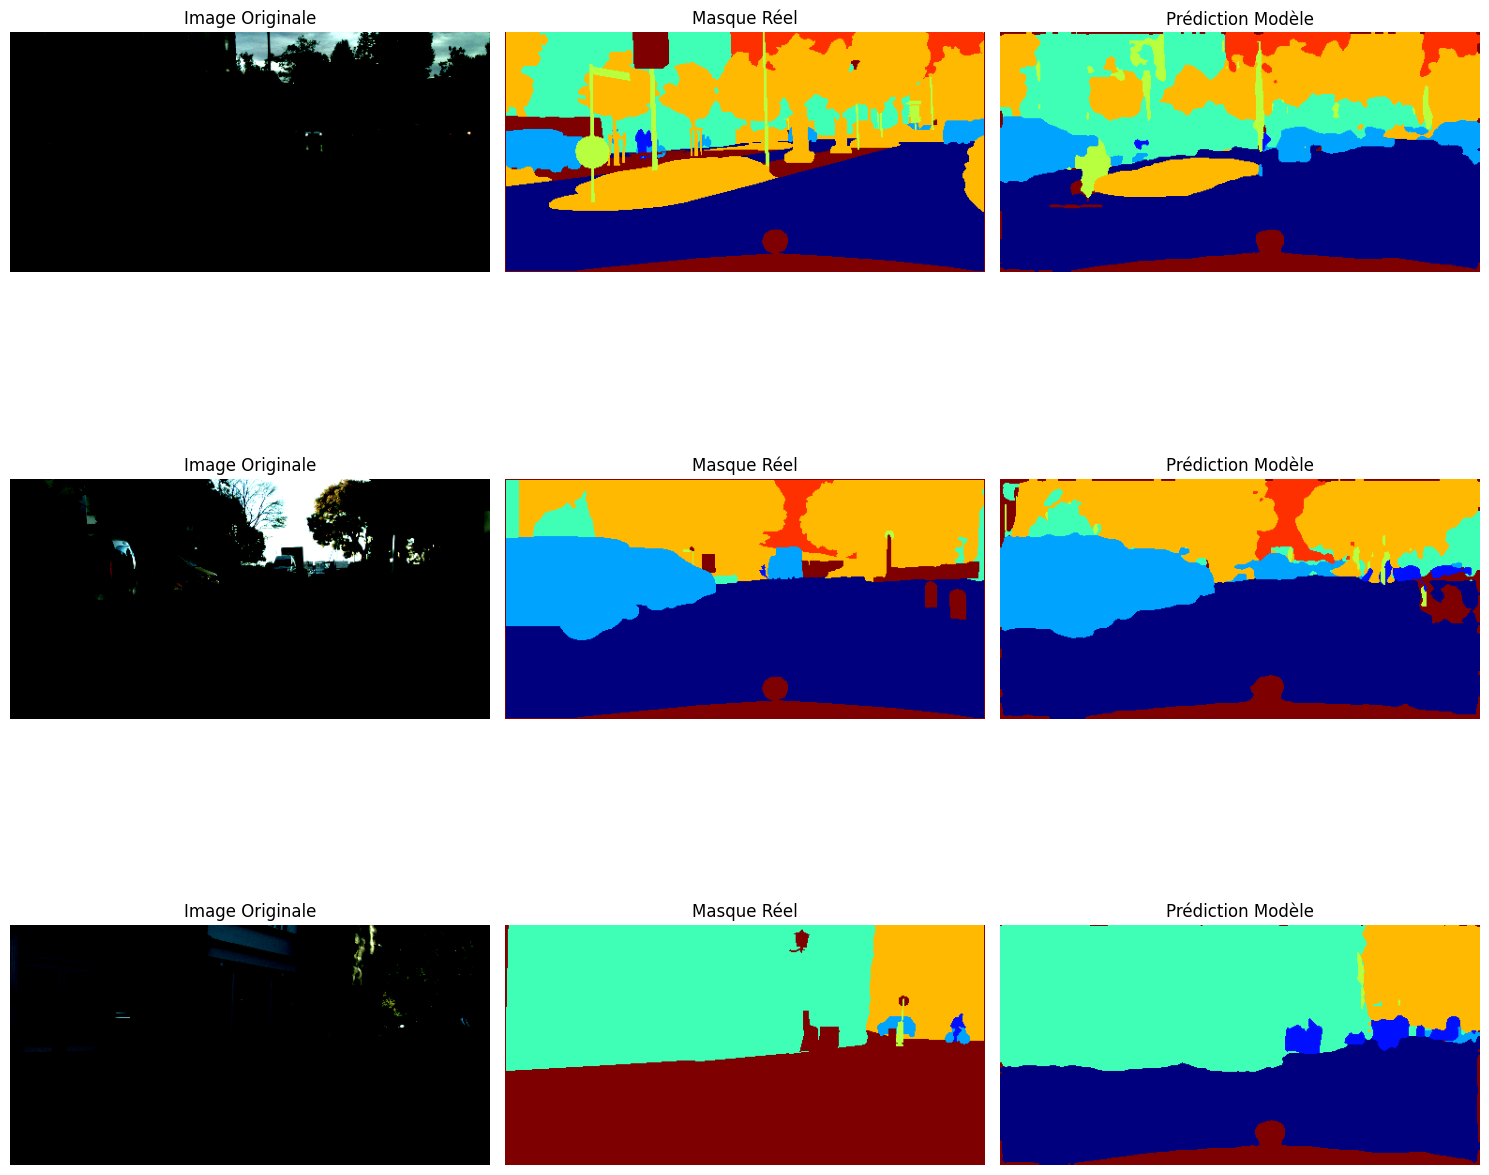

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataset, num_samples=3):
    """ Affiche Image Réelle / Masque Réel / Masque Predit """

    # Récupérer un batch
    for images, masks in dataset.take(1):
        # Prédiction
        preds = model.predict(images)
        # Argmax pour avoir la classe dominante par pixel
        preds = np.argmax(preds, axis=-1)

        plt.figure(figsize=(15, 5 * num_samples))

        for i in range(num_samples):
            # 1. Image Originale
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow(images[i])
            plt.title("Image Originale")
            plt.axis("off")

            # 2. Masque Réel (Ground Truth)
            plt.subplot(num_samples, 3, i*3 + 2)
            plt.imshow(masks[i], cmap='jet', vmin=0, vmax=7)
            plt.title("Masque Réel")
            plt.axis("off")

            # 3. Prédiction
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(preds[i], cmap='jet', vmin=0, vmax=7)
            plt.title("Prédiction Modèle")
            plt.axis("off")

        plt.tight_layout()
        plt.show()
        break

# Lancer la visualisation sur le dataset de validation
# (Utilise le dernier modèle en mémoire, assurez-vous d'avoir entraîné un modèle avant)
try:
    print("Visualisation avec le dernier modèle entraîné...")
    visualize_predictions(model_deeplab_aug, val_ds) # Remplacez par le modèle que vous voulez tester
except NameError:
    print("Veuillez d'abord entraîner un modèle (ex: model_deeplab_aug) avant de visualiser.")